In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
modeling_data = pd.read_csv('../data/modeling_data.csv', sep = ',')
modeling_data

,likes_log,likes_log_scaled,likes_log_minmax,likes_log_zscore,likes_log_win,likes_log_win_scaled,likes_log_win_minmax,likes_log_win_zscore,comments_log_minmax,comments_log_scaled,...,comments_log_win,comments_log_win_zscore,duration_log_minmax,duration_log_zscore,duration_log,duration_log_scaled,has_description,comments,views,views_log
0,3.737670,0.274072,0.274072,1.674128,3.737670,0.928938,0.928938,2.215592,0.142634,0.142634,...,1.386294,1.750704,0.475912,0.344115,5.198497,0.511668,1,3,4078,8.313607
1,1.098612,0.080558,0.080558,-0.003934,1.098612,0.273042,0.273042,0.080232,0.071317,0.071317,...,0.693147,0.596950,0.648914,1.680595,6.836259,0.672866,1,1,33,3.526361
2,4.912655,0.360230,0.360230,2.421250,4.023595,1.000000,1.000000,2.446945,0.297386,0.297386,...,1.732868,2.327581,0.503041,0.553694,5.455321,0.536946,1,17,13227,9.490091
3,0.693147,0.050826,0.050826,-0.261751,0.693147,0.172271,0.172271,-0.247845,0.000000,0.000000,...,0.000000,-0.556803,0.595783,1.270144,6.333280,0.623360,1,0,43,3.784190
4,1.098612,0.080558,0.080558,-0.003934,1.098612,0.273042,0.273042,0.080232,0.000000,0.000000,...,0.000000,-0.556803,0.529639,0.759164,5.707110,0.561728,1,0,222,5.407172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,0.000000,0.000000,0.000000,-0.702493,0.000000,0.000000,0.000000,-0.808696,0.000000,0.000000,...,0.000000,-0.556803,0.597458,1.283086,6.349139,0.624921,0,0,27,3.332205
17582,0.693147,0.050826,0.050826,-0.261751,0.693147,0.172271,0.172271,-0.247845,0.000000,0.000000,...,0.000000,-0.556803,0.419393,-0.092514,4.663439,0.459004,0,0,295,5.690359
17583,1.386294,0.101653,0.101653,0.178991,1.386294,0.344541,0.344541,0.313007,0.000000,0.000000,...,0.000000,-0.556803,0.464198,0.253615,5.087596,0.500752,0,0,770,6.647688
17584,0.693147,0.050826,0.050826,-0.261751,0.693147,0.172271,0.172271,-0.247845,0.000000,0.000000,...,0.000000,-0.556803,0.526432,0.734392,5.676754,0.558740,1,0,42,3.761200


In [20]:
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17586 entries, 0 to 17585
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   likes_log                17586 non-null  float64
 1   likes_log_scaled         17586 non-null  float64
 2   likes_log_minmax         17586 non-null  float64
 3   likes_log_zscore         17586 non-null  float64
 4   likes_log_win            17586 non-null  float64
 5   likes_log_win_scaled     17586 non-null  float64
 6   likes_log_win_minmax     17586 non-null  float64
 7   likes_log_win_zscore     17586 non-null  float64
 8   comments_log_minmax      17586 non-null  float64
 9   comments_log_scaled      17586 non-null  float64
 10  comments_log             17586 non-null  float64
 11  comments_log_zscore      17586 non-null  float64
 12  comments_log_win_scaled  17586 non-null  float64
 13  comments_log_win_minmax  17586 non-null  float64
 14  comments_log_win      

In [ ]:
feature_cols = [
    'likes_log_zscore',
    'comments_log_zscore',
    'duration_log_zscore',
    'has_description'
]


In [11]:
X = modeling_data.drop(columns=['views_log'])
y = modeling_data['views_log']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: Linear Regression
pipeline = Pipeline([
    ('linear', LinearRegression())
])

# Fit mô hình
pipeline.fit(X_train, y_train)

# Predict on log scale
y_pred_log = pipeline.predict(X_test)

# --- Đánh giá trên log scale ---
mse_log = mean_squared_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)
print(f"Log scale -> MSE: {mse_log:.4f}, R2: {r2_log:.4f}")

# --- Đánh giá trên original scale ---
y_test_orig = np.expm1(y_test)        # true values
y_pred_orig = np.expm1(y_pred_log)    # predicted values (convert from log)
mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
r2_orig = r2_score(y_test_orig, y_pred_orig)
print(f"Original scale -> MSE: {mse_orig:.4f}, R2: {r2_orig:.4f}")

Log scale -> MSE: 1.9348, R2: 0.6768
Original scale -> MSE: 3500099481032.0684, R2: 0.9272


In [15]:
!pip install statsmodels


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


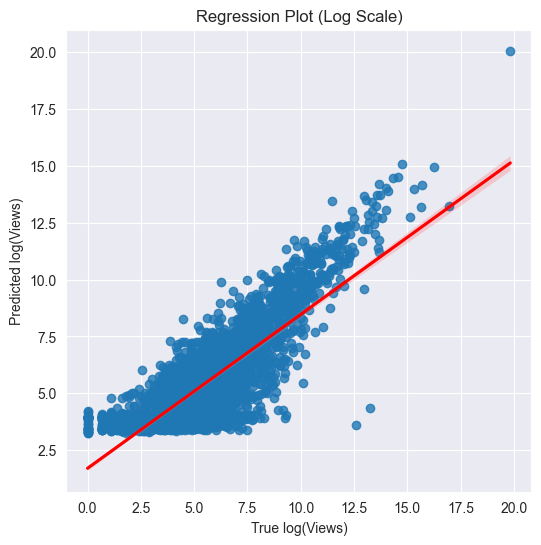

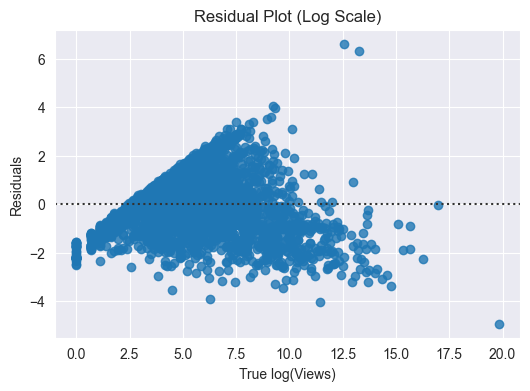

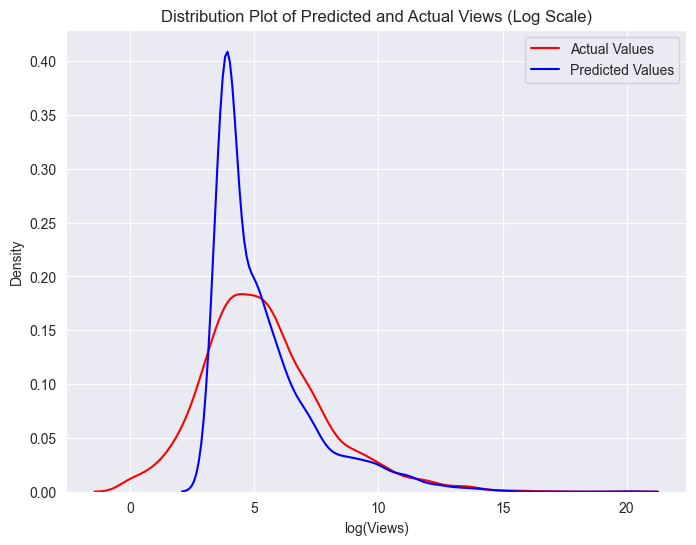

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

y_true = y_test       # log scale
y_pred = y_pred_log   # log scale
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Views)")
plt.ylabel("Predicted log(Views)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})  # lowess vẫn optional
plt.xlabel("True log(Views)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual Values')
sns.kdeplot(y_pred, color='blue', label='Predicted Values')
plt.title('Distribution Plot of Predicted and Actual Views (Log Scale)')
plt.xlabel('log(Views)')
plt.ylabel('Density')
plt.legend()
plt.show()